In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cds.pricing.cds_engine import CDS, Params
from cds.data.build_portfolio import spreads_to_df, market_data
from cds.correlation.gaussian_copula import implied_rho

In [2]:
params = Params(T=5, freq=4, r=0.02, recovery=0.4, coupon=0.05)
cds = CDS(params)
df = spreads_to_df().groupby('Date')
print(df.head(n=20))

                    Company       Date  cds_flat_spread
44   ADLER Real Estate GmbH 2025-03-31          274.580
43   ADLER Real Estate GmbH 2025-04-01          271.700
42   ADLER Real Estate GmbH 2025-04-02          271.695
41   ADLER Real Estate GmbH 2025-04-03          271.740
40   ADLER Real Estate GmbH 2025-04-04          290.645
..                      ...        ...              ...
859                ELO SACA 2025-05-26          483.315
858                ELO SACA 2025-05-27          467.990
857                ELO SACA 2025-05-28          467.235
856                ELO SACA 2025-05-29          472.125
855                ELO SACA 2025-05-30          466.895

[900 rows x 3 columns]


### Calculate and plot the index flat spread for each day

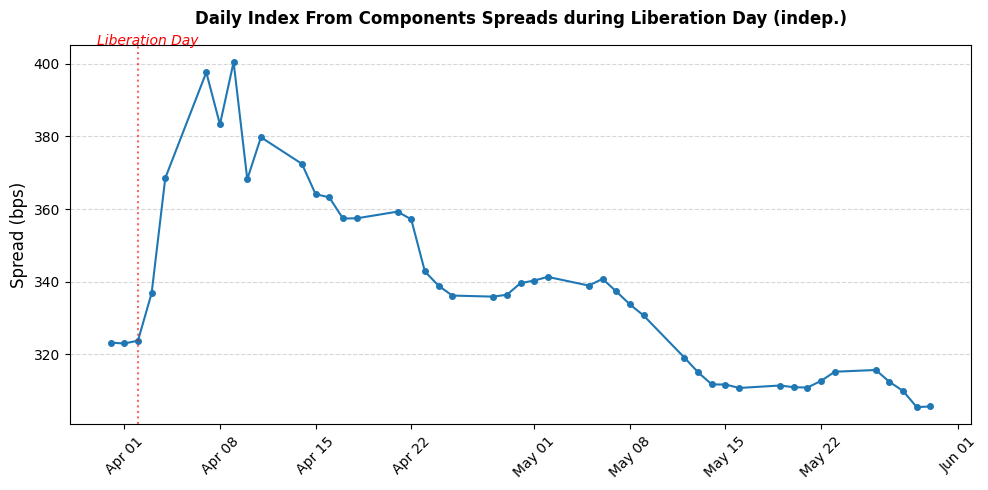

In [3]:
daily_index_spreads = []
for date, df_day in df:
    res = cds.index_from_component_spreads(df_day)
    daily_index_spreads.append({
        'date': date,
        'index_from_components': res['index_flat_calc_bp'],
    })
daily_index_spreads_df = pd.DataFrame(daily_index_spreads)

daily_index_spreads_df['date'] = pd.to_datetime(daily_index_spreads_df['date'])
plt.figure(figsize=(10, 5))
plt.plot(
    daily_index_spreads_df['date'], 
    daily_index_spreads_df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4'
)
plt.title('Daily Index From Components Spreads during Liberation Day (indep.)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 
liberation_day = pd.to_datetime('2025-04-02')
plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.6)
plt.text(
    liberation_day - pd.Timedelta(days=3),
    1, 
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Combine with Market Data (Spreads)

In [4]:
df_market_spreads = market_data()
df_market_spreads['date'] = pd.to_datetime(df_market_spreads['date'])
df_market_spreads['value'] = df_market_spreads['value'] * 10000
df_market = df_market_spreads[df_market_spreads['date'].between('2024-04-01', '2025-05-30')]

df = daily_index_spreads_df.merge(df_market, on='date', how='inner')

print(df.head(n=200))

         date  index_from_components       value
0  2025-03-31             323.228583  328.161750
1  2025-04-01             322.991025  326.556100
2  2025-04-02             323.769594  327.288778
3  2025-04-03             336.837210  348.764650
4  2025-04-04             368.541492  388.812143
5  2025-04-07             397.630124  407.216625
6  2025-04-08             383.301892  393.518182
7  2025-04-09             400.458658  427.436667
8  2025-04-10             368.208438  389.662778
9  2025-04-11             379.766503  390.554375
10 2025-04-14             372.440665  372.388250
11 2025-04-15             364.104275  365.871182
12 2025-04-16             363.226469  366.500909
13 2025-04-17             357.403702  366.132778
14 2025-04-18             357.440043  366.132778
15 2025-04-21             359.290179  366.132778
16 2025-04-22             357.162610  365.683278
17 2025-04-23             342.817057  350.633556
18 2025-04-24             338.892248  344.916364
19 2025-04-25       

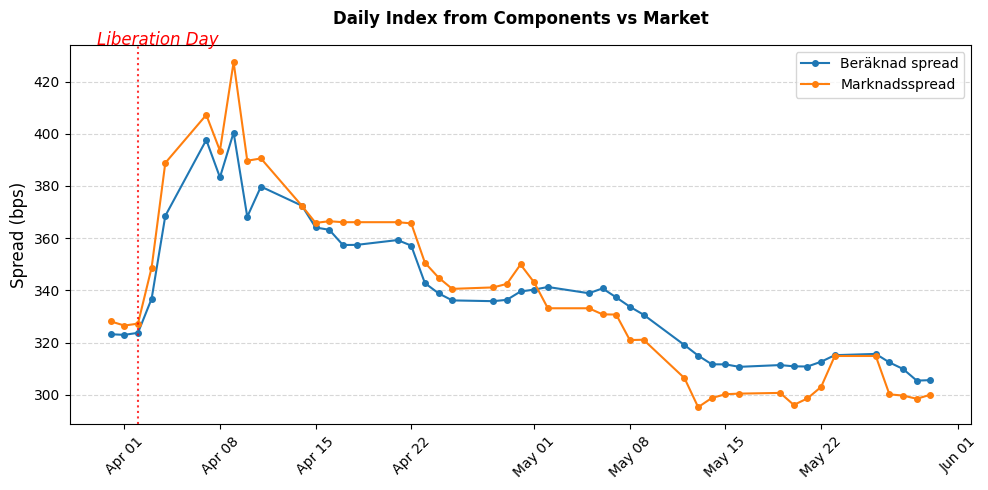

In [5]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(10, 5))

plt.plot(
    df['date'], 
    df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4',
    label='Beräknad spread'
)

plt.plot(
    df['date'], 
    df['value'], 
    color='#ff7f0e', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#ff7f0e',
    label='Marknadsspread'
)
plt.title('Daily Index from Components vs Market', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 

liberation_day = pd.to_datetime('2025-04-02')

plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.8)
plt.text(
    liberation_day - pd.Timedelta(days=3), 
    1,                               
    'Liberation Day', 
    color='red', 
    fontsize=12, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Difference

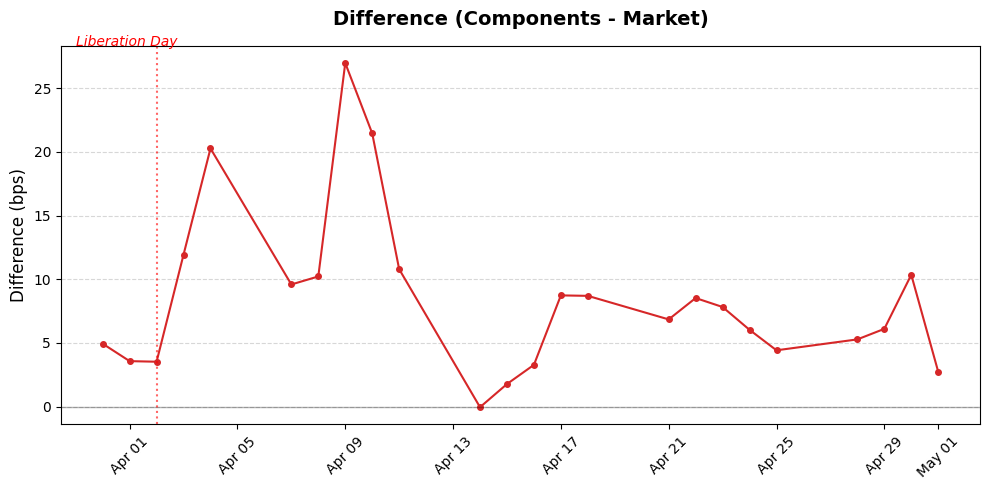

In [6]:
df_diff = df.copy()
df_diff["diff"] = df_diff['value'] - df_diff['index_from_components'] 
df_diff = df_diff[df_diff['date'].between('2024-04-01', '2025-05-01')]

plt.figure(figsize=(10, 5))

plt.plot(
    df_diff['date'], 
    df_diff['diff'], 
    color='#d62728',       
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#d62728',
    label='Basis (Marknad minus Beräknad)'
)

plt.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.3)

plt.title('Difference (Components - Market)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Difference (bps)', fontsize=12)
plt.xlabel('') 

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 

target_date = pd.to_datetime('2025-04-02')

plt.axvline(x=target_date, color='red', linestyle=':', alpha=0.6)
plt.text(
    target_date - pd.Timedelta(days=3), 
    1,                               
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Find implied rho using a one factor Gaussian Copula Model to "explain" the difference

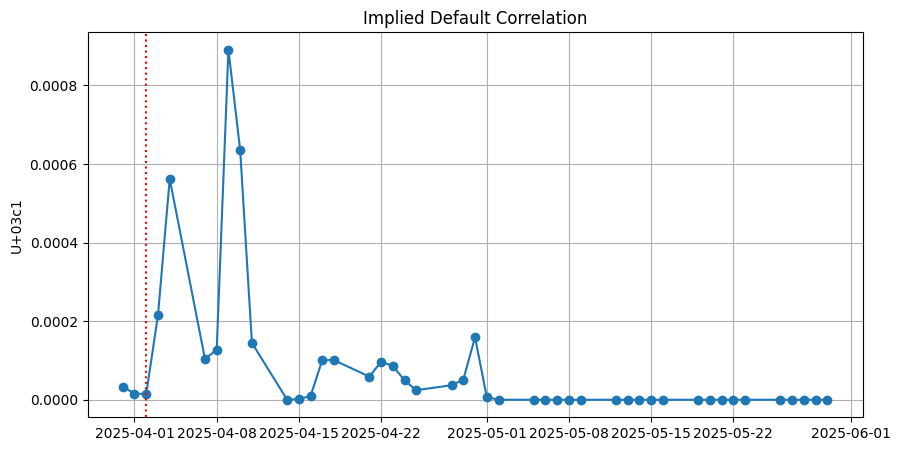

In [ ]:
df_groups = spreads_to_df().groupby("Date")

implied_corr = []

for date, df_day in df_groups:

    market_spread = df[df["date"] == date]["value"].values[0]

    rho = implied_rho(df_day, market_spread, cds)

    implied_corr.append({
        "date": date,
        "rho": rho
    })

df_corr = pd.DataFrame(implied_corr)

plt.figure(figsize=(10,5))
plt.plot(df_corr["date"], df_corr["rho"], marker="o")
plt.axvline(pd.to_datetime("2025-04-02"), color="red", linestyle=":")
plt.title("Implied Default Correlation")
plt.ylabel("rho") 
plt.grid(True)
plt.show()